# Autoencoders and Anomaly Detection

## Datasets and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

# ── Digits ─────────────────────────────────────────────────────────────────
digits    = load_digits()
print(f"Digits loaded: X shape = {digits.data.shape}")

X_dig     = digits.data
y_dig     = digits.target
X_dig_sc  = MinMaxScaler().fit_transform(X_dig)
print("Digits scaling done.")

# ── Wholesale Customers ────────────────────────────────────────────────────
ws_url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
          "/00292/Wholesale%20customers%20data.csv")
df_ws = pd.read_csv(ws_url)
print(f"Wholesale data loaded: shape = {df_ws.shape}")

df_ws.columns = df_ws.columns.str.strip().str.lower().str.replace(" ","_")
spend_cols = ["fresh","milk","grocery","frozen","detergents_paper","delicassen"]
X_ws       = df_ws[spend_cols].values
channel    = df_ws["channel"].values

X_ws_log    = np.log1p(X_ws)
scaler_ws   = StandardScaler()
X_ws_scaled = scaler_ws.fit_transform(X_ws_log)
print("Wholesale preprocessing done.")

print("✅ All preprocessing finished successfully!")

Digits loaded: X shape = (1797, 64)
Digits scaling done.
Wholesale data loaded: shape = (440, 8)
Wholesale preprocessing done.
✅ All preprocessing finished successfully!


## Autoencoder Architecture and Training

### Architecture

Final training MSE : 0.040188


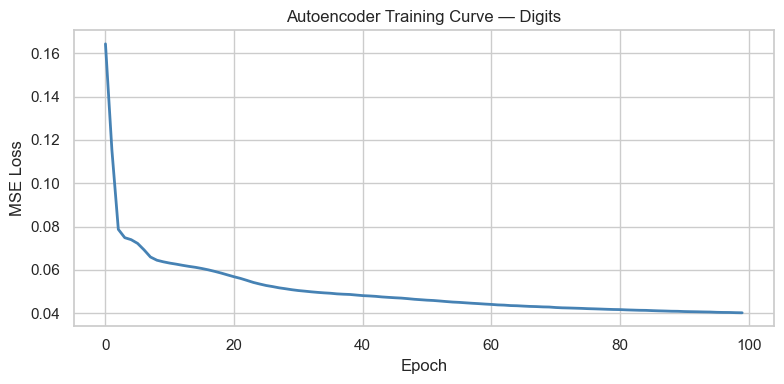

In [2]:
X_tensor = torch.tensor(X_dig_sc, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=64, shuffle=True,
                      generator=torch.Generator().manual_seed(RANDOM_SEED))

INPUT_DIM  = 64
HIDDEN_DIM = 32
LATENT_DIM = 2   # 2D for comparison with PCA/t-SNE visualisations

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(INPUT_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, INPUT_DIM),
            nn.Sigmoid()
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

torch.manual_seed(RANDOM_SEED)
model     = Autoencoder(latent_dim=LATENT_DIM)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

N_EPOCHS     = 100
train_losses = []

model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        x_hat, _ = model(batch)
        loss = criterion(x_hat, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(dataset))

print(f"Final training MSE : {train_losses[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color="steelblue", lw=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Curve — Digits")
plt.tight_layout()
plt.savefig(FIGURES / "ch7_ae_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Latent Space and Reconstruction Quality

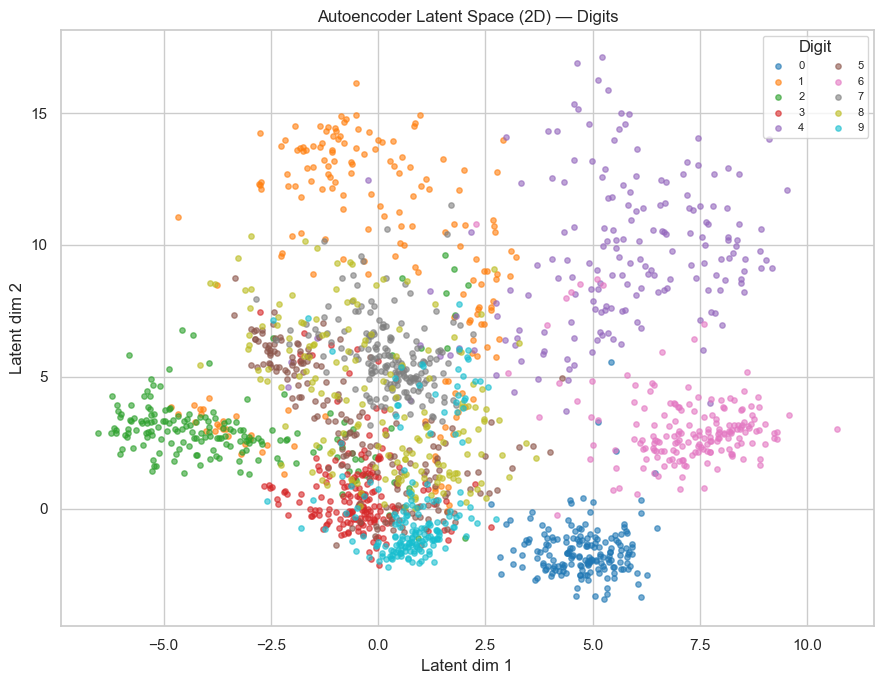

Reconstruction MSE — PCA (2 components) : 0.053412
Reconstruction MSE — Autoencoder (2D)   : 0.040000
Relative improvement (AE vs PCA)        : 25.1%


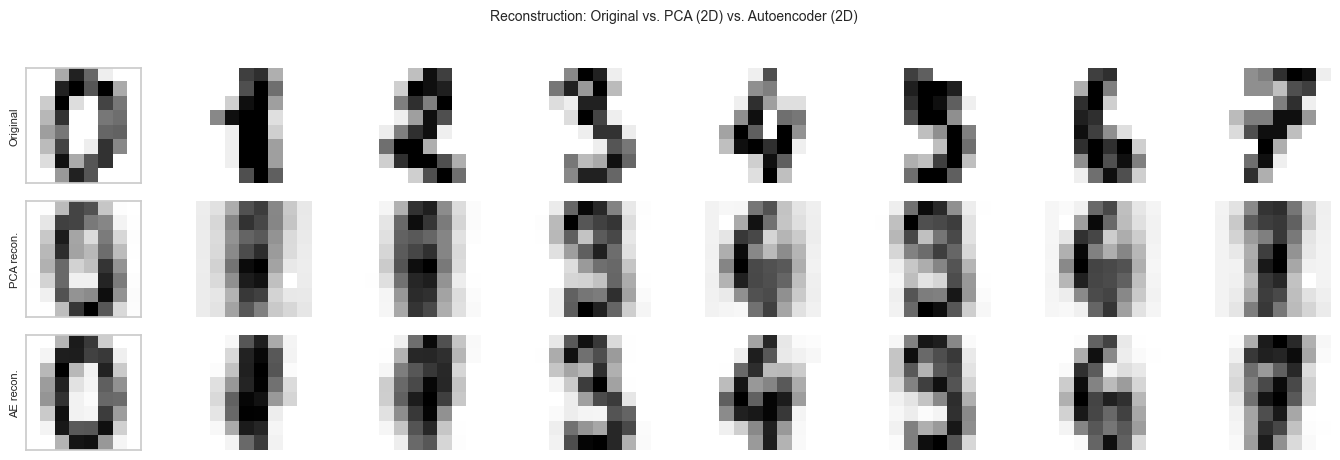

In [3]:
model.eval()
with torch.no_grad():
    x_hat_all, Z = model(X_tensor)
    Z_np         = Z.numpy()
    x_hat_np     = x_hat_all.numpy()

# ── Latent scatter ─────────────────────────────────────────────────────────
colors_dig = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax    = plt.subplots(figsize=(9, 7))
for d in range(10):
    m = y_dig == d
    ax.scatter(Z_np[m,0], Z_np[m,1], c=[colors_dig[d]],
               alpha=0.6, s=15, label=str(d))
ax.set_xlabel("Latent dim 1"); ax.set_ylabel("Latent dim 2")
ax.set_title("Autoencoder Latent Space (2D) — Digits")
ax.legend(title="Digit", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES / "ch7_ae_latent.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PCA vs. AE reconstruction MSE ──────────────────────────────────────────
from sklearn.decomposition import PCA

pca_2d     = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_r    = pca_2d.fit_transform(X_dig_sc)
X_pca_rec  = pca_2d.inverse_transform(X_pca_r)

mse_pca = np.mean((X_dig_sc - X_pca_rec)**2)
mse_ae  = np.mean((X_dig_sc - x_hat_np)**2)
print(f"Reconstruction MSE — PCA (2 components) : {mse_pca:.6f}")
print(f"Reconstruction MSE — Autoencoder (2D)   : {mse_ae:.6f}")
print(f"Relative improvement (AE vs PCA)        : {(mse_pca-mse_ae)/mse_pca:.1%}")

# ── Visual reconstruction comparison (8 digits) ────────────────────────────
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(14, 4.5))
labels = ["Original", "PCA recon.", "AE recon."]
for col in range(n_show):
    axes[0,col].imshow(X_dig_sc[col].reshape(8,8),  cmap="gray_r")
    axes[1,col].imshow(X_pca_rec[col].reshape(8,8), cmap="gray_r")
    axes[2,col].imshow(x_hat_np[col].reshape(8,8),  cmap="gray_r")
    for row in range(3):
        axes[row,col].axis("off")
        if col == 0:
            axes[row,col].set_ylabel(labels[row], fontsize=8)
            axes[row,col].axis("on")
            axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
plt.suptitle("Reconstruction: Original vs. PCA (2D) vs. Autoencoder (2D)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch7_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

## Deeper Autoencoders

In [4]:
class DeepAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.Sigmoid()
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

results = []
for latent_dim in [2, 4, 8, 16]:
    torch.manual_seed(RANDOM_SEED)
    m     = DeepAutoencoder(latent_dim)
    opt   = optim.Adam(m.parameters(), lr=1e-3)
    crit  = nn.MSELoss()

    m.train()
    for _ in range(150):
        for (batch,) in loader:
            opt.zero_grad()
            xh, _ = m(batch)
            loss   = crit(xh, batch)
            loss.backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        xh, Z = m(X_tensor)
    Z_np  = Z.numpy()
    xh_np = xh.numpy()

    mse  = np.mean((X_dig_sc - xh_np)**2)
    acc  = cross_val_score(
               LogisticRegression(max_iter=500),
               Z_np, y_dig, cv=5, scoring="accuracy").mean()
    results.append({"latent_dim": latent_dim, "MSE": mse, "CV_Acc": acc})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

 latent_dim      MSE   CV_Acc
          2 0.026348 0.695624
          4 0.016555 0.817499
          8 0.008731 0.900407
         16 0.006612 0.923210


## Anomaly Detection

### Isolation Forest

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ── Isolation Forest ───────────────────────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=0.05,
                      random_state=RANDOM_SEED)
iso_labels  = iso.fit_predict(X_ws_scaled)   # -1 = anomaly, 1 = normal
iso_scores  = -iso.score_samples(X_ws_scaled) # higher = more anomalous

n_anomalies_iso = (iso_labels == -1).sum()
print(f"Isolation Forest : {n_anomalies_iso} anomalies detected "
      f"({n_anomalies_iso/len(X_ws_scaled):.1%} of dataset)")
print("\nTop 5 anomalies by IF score:")
top_iso = np.argsort(iso_scores)[::-1][:5]
print(pd.DataFrame(X_ws, columns=spend_cols).iloc[top_iso].round(0).to_string())

Isolation Forest : 22 anomalies detected (5.0% of dataset)

Top 5 anomalies by IF score:
     fresh   milk  grocery  frozen  detergents_paper  delicassen
154    622     55      137      75                 7           8
338      3    333     7021   15601                15         550
183  36847  43950    20170   36534               239       47943
75   20398   1137        3    4407                 3         975
65      85  20959    45828      36             24231        1423


### Local Outlier Factor

In [6]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_ws_scaled)   # -1 = anomaly, 1 = normal
lof_scores = -lof.negative_outlier_factor_   # higher = more anomalous

n_anomalies_lof = (lof_labels == -1).sum()
print(f"LOF : {n_anomalies_lof} anomalies detected "
      f"({n_anomalies_lof/len(X_ws_scaled):.1%} of dataset)")

# ── Agreement between methods ──────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score
ari_methods = adjusted_rand_score(
    (iso_labels == -1).astype(int),
    (lof_labels == -1).astype(int)
)
print(f"\nARI (Isolation Forest vs. LOF) : {ari_methods:.4f}")
both_anomalies = ((iso_labels == -1) & (lof_labels == -1)).sum()
print(f"Flagged by both methods        : {both_anomalies}")

LOF : 22 anomalies detected (5.0% of dataset)

ARI (Isolation Forest vs. LOF) : 0.4952
Flagged by both methods        : 12


### Visualising Anomalies

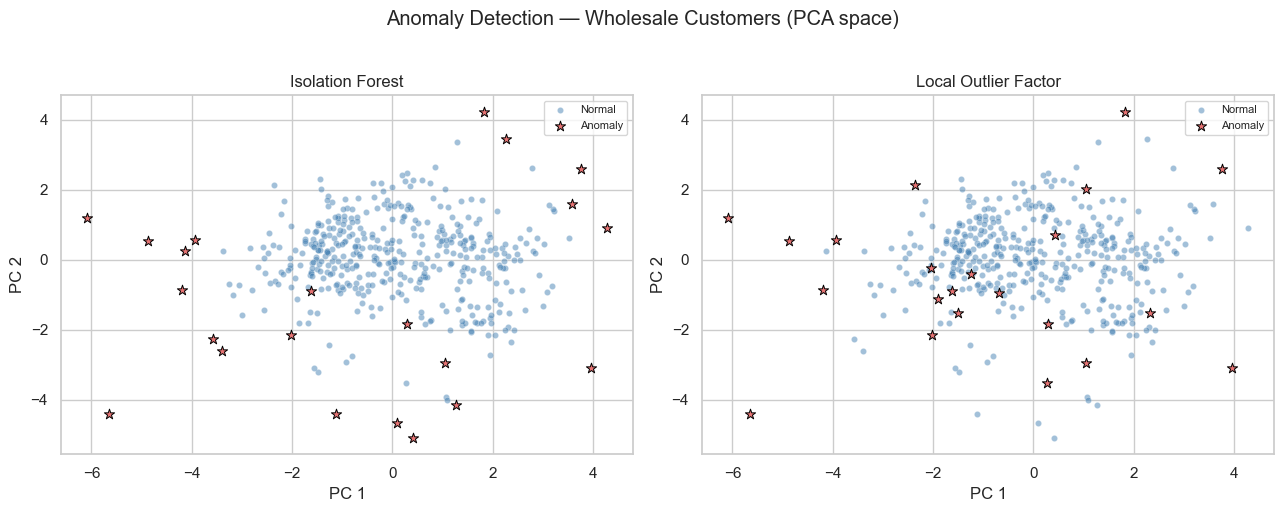

In [7]:
from sklearn.decomposition import PCA as _PCA

pca_ad = _PCA(n_components=2, random_state=RANDOM_SEED)
X_ad2  = pca_ad.fit_transform(X_ws_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
method_labels = [
    (iso_labels, iso_scores, "Isolation Forest"),
    (lof_labels, lof_scores, "Local Outlier Factor"),
]
for ax, (labels, scores, title) in zip(axes, method_labels):
    normal_mask  = labels == 1
    anomaly_mask = labels == -1

    sc = ax.scatter(X_ad2[normal_mask,0],  X_ad2[normal_mask,1],
                    c="steelblue", alpha=0.5, s=20,
                    edgecolors="white", lw=0.3, label="Normal")
    ax.scatter(X_ad2[anomaly_mask,0], X_ad2[anomaly_mask,1],
               c="#E57373", s=60, zorder=5,
               edgecolors="black", lw=0.7, label="Anomaly", marker="*")
    ax.set_title(title)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(fontsize=8)

plt.suptitle("Anomaly Detection — Wholesale Customers (PCA space)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch7_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

### Autoencoder-Based Anomaly Detection

In [8]:
# ── Train autoencoder on Wholesale Customers data ─────────────────────────
X_ws_tensor = torch.tensor(X_ws_scaled, dtype=torch.float32)
ws_dataset  = TensorDataset(X_ws_tensor)
ws_loader   = DataLoader(ws_dataset, batch_size=32, shuffle=True,
                         generator=torch.Generator().manual_seed(RANDOM_SEED))

class WSAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(6,12),nn.ReLU(),nn.Linear(12,3))
        self.decoder = nn.Sequential(nn.Linear(3,12),nn.ReLU(),nn.Linear(12,6))
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

torch.manual_seed(RANDOM_SEED)
ws_model  = WSAutoencoder()
ws_opt    = optim.Adam(ws_model.parameters(), lr=1e-3)
ws_crit   = nn.MSELoss(reduction="none")

ws_model.train()
for _ in range(200):
    for (batch,) in ws_loader:
        ws_opt.zero_grad()
        xh, _ = ws_model(batch)
        loss   = ws_crit(xh, batch).mean()
        loss.backward()
        ws_opt.step()

ws_model.eval()
with torch.no_grad():
    xh_ws, _ = ws_model(X_ws_tensor)
    recon_err = ws_crit(xh_ws, X_ws_tensor).mean(dim=1).numpy()

threshold   = np.percentile(recon_err, 95)
ae_anomaly  = recon_err > threshold

print(f"AE anomaly threshold (95th pct) : {threshold:.6f}")
print(f"AE anomalies detected           : {ae_anomaly.sum()}")
print(f"\nARI (AE vs. Isolation Forest)   : "
      f"{adjusted_rand_score(ae_anomaly.astype(int), (iso_labels==-1).astype(int)):.4f}")
print(f"ARI (AE vs. LOF)                : "
      f"{adjusted_rand_score(ae_anomaly.astype(int), (lof_labels==-1).astype(int)):.4f}")

AE anomaly threshold (95th pct) : 0.447562
AE anomalies detected           : 22

ARI (AE vs. Isolation Forest)   : 0.1705
ARI (AE vs. LOF)                : 0.4952


## Connecting Unsupervised and Supervised Learning

### PCA Preprocessing

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

results_pca = []
for n_comp in [5, 10, 20, 30, 50, 64]:
    if n_comp < 64:
        pipe = Pipeline([
            ("scaler", MinMaxScaler()),
            ("pca",    PCA(n_components=n_comp, random_state=RANDOM_SEED)),
            ("clf",    LogisticRegression(max_iter=500, random_state=RANDOM_SEED))
        ])
    else:
        pipe = Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf",    LogisticRegression(max_iter=500, random_state=RANDOM_SEED))
        ])
    acc = cross_val_score(pipe, X_dig, y_dig, cv=5, scoring="accuracy").mean()
    results_pca.append({"n_components": n_comp, "CV_Accuracy": acc})

res_pca_df = pd.DataFrame(results_pca)
print(res_pca_df.to_string(index=False))

 n_components  CV_Accuracy
            5     0.824732
           10     0.893169
           20     0.920987
           30     0.927109
           50     0.929342
           64     0.929898


### Cluster Labels as Features

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

# ── Use wholesale channel (Horeca=1, Retail=2) as binary target ───────────
y_binary = (channel == 2).astype(int)   # 1=Retail, 0=Horeca

km4 = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_SEED)
km4_labels = km4.fit_predict(X_ws_scaled)

# One-hot encode cluster membership and append to features
cluster_ohe = pd.get_dummies(km4_labels, prefix="cluster").values
X_augmented = np.hstack([X_ws_scaled, cluster_ohe])

lr_base = LogisticRegression(max_iter=300, random_state=RANDOM_SEED)
lr_aug  = LogisticRegression(max_iter=300, random_state=RANDOM_SEED)

auc_base = cross_val_score(lr_base, X_ws_scaled, y_binary,
                            cv=5, scoring="roc_auc").mean()
auc_aug  = cross_val_score(lr_aug,  X_augmented, y_binary,
                            cv=5, scoring="roc_auc").mean()

print(f"Logistic regression AUC — raw features only     : {auc_base:.4f}")
print(f"Logistic regression AUC — + cluster OHE features : {auc_aug:.4f}")
print(f"Improvement                                      : "
      f"{auc_aug - auc_base:+.4f}")

Logistic regression AUC — raw features only     : 0.9629
Logistic regression AUC — + cluster OHE features : 0.9629
Improvement                                      : +0.0000
